In [31]:
#Importacion de librerias
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

In [32]:
#Carga de datos
df_companies = pd.read_csv("../datasets/moved_project_sql_result_01.csv")
df_neighborhoods = pd.read_csv("../datasets/moved_project_sql_result_04.csv")
df_rides = pd.read_csv("../datasets/moved_project_sql_result_07.csv")

In [33]:
#Exploracion de datos inicial
df_companies.head()

,company_name,trips_amount
0,Flash Cab,19558
1,Taxi Affiliation Services,11422
2,Medallion Leasin,10367
3,Yellow Cab,9888
4,Taxi Affiliation Service Yellow,9299


In [34]:
df_neighborhoods.head()

,dropoff_location_name,average_trips
0,Loop,10727.466667
1,River North,9523.666667
2,Streeterville,6664.666667
3,West Loop,5163.666667
4,O'Hare,2546.900000


In [35]:
df_rides.head()

,start_ts,weather_conditions,duration_seconds
0,2017-11-25 16:00:00,Good,2410.0
1,2017-11-25 14:00:00,Good,1920.0
2,2017-11-25 12:00:00,Good,1543.0
3,2017-11-04 10:00:00,Good,2512.0
4,2017-11-11 07:00:00,Good,1440.0


In [ ]:
# aqui convierto la fecha a formato datetime para que el tipo de dato sea correcto
df_rides["start_ts"] = pd.to_datetime(df_rides["start_ts"])

Observamos que los datos contienen información sobre:
- empresas de taxis
- barrios
- viajes y condiciones climáticas

In [36]:
# info general
df_companies.info()

<class 'pandas.DataFrame'>
RangeIndex: 64 entries, 0 to 63
Data columns (total 2 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   company_name  64 non-null     str  
 1   trips_amount  64 non-null     int64
dtypes: int64(1), str(1)
memory usage: 1.1 KB


In [ ]:
df_neighborhoods.info()

<class 'pandas.DataFrame'>
RangeIndex: 64 entries, 0 to 63
Data columns (total 2 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   company_name  64 non-null     str  
 1   trips_amount  64 non-null     int64
dtypes: int64(1), str(1)
memory usage: 1.1 KB


In [38]:
df_rides.info()

<class 'pandas.DataFrame'>
RangeIndex: 1068 entries, 0 to 1067
Data columns (total 3 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   start_ts            1068 non-null   str    
 1   weather_conditions  1068 non-null   str    
 2   duration_seconds    1068 non-null   float64
dtypes: float64(1), str(2)
memory usage: 25.2 KB


In [39]:
# valores nulos
df_companies.isna().sum()

company_name    0
trips_amount    0
dtype: int64

In [40]:
df_neighborhoods.isna().sum()

dropoff_location_name    0
average_trips            0
dtype: int64

In [41]:
df_rides.isna().sum()

start_ts              0
weather_conditions    0
duration_seconds      0
dtype: int64

No se encontraron valores nulos en ninguno de los datasets.

Esto indica que los datos están completos y no es necesario realizar procesos de limpieza relacionados con valores faltantes.

In [42]:
top_neighborhoods = df_neighborhoods.sort_values(
    by="average_trips",
    ascending=False
).head(10)

top_neighborhoods

,dropoff_location_name,average_trips
0,Loop,10727.466667
1,River North,9523.666667
2,Streeterville,6664.666667
3,West Loop,5163.666667
4,O'Hare,2546.900000
5,Lake View,2420.966667
6,Grant Park,2068.533333
7,Museum Campus,1510.000000
8,Gold Coast,1364.233333
9,Sheffield & DePaul,1259.766667


Se identificaron los 10 barrios con mayor promedio de finalización de viajes.
Esto permite analizar las zonas con mayor demanda de transporte.

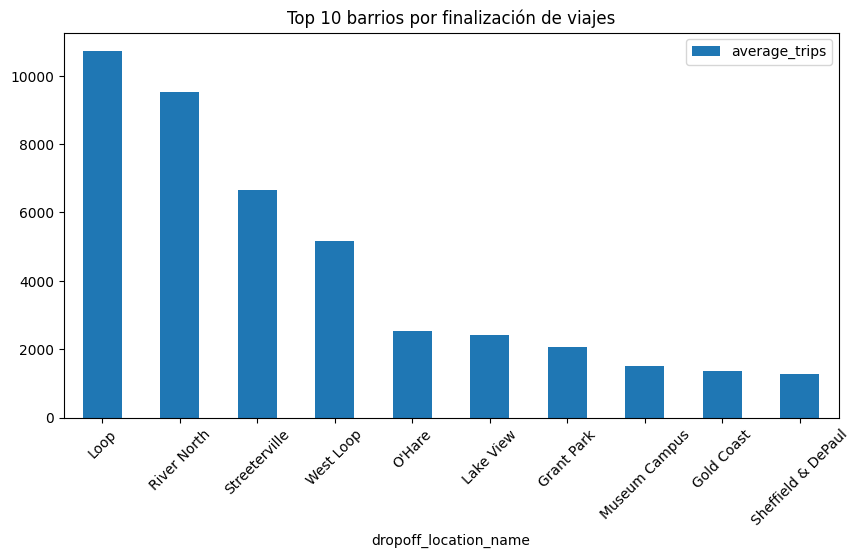

In [43]:
import matplotlib.pyplot as plt

top_neighborhoods.plot(
    x="dropoff_location_name",
    y="average_trips",
    kind="bar",
    figsize=(10,5)
)

plt.title("Top 10 barrios por finalización de viajes")
plt.xticks(rotation=45)
plt.show()

Los barrios con mayor número de viajes indican zonas con alta actividad.
Esto puede estar relacionado con áreas comerciales, turísticas o con alta densidad de población.

In [44]:
df_companies_sorted = df_companies.sort_values(
    by="trips_amount",
    ascending=False
)

df_companies_sorted.head(10)

,company_name,trips_amount
0,Flash Cab,19558
1,Taxi Affiliation Services,11422
2,Medallion Leasin,10367
3,Yellow Cab,9888
4,Taxi Affiliation Service Yellow,9299
5,Chicago Carriage Cab Corp,9181
6,City Service,8448
7,Sun Taxi,7701
8,Star North Management LLC,7455
9,Blue Ribbon Taxi Association Inc.,5953


Se ordenaron las empresas de taxis según el número de viajes realizados.

Esto permite identificar qué compañías dominan el mercado.

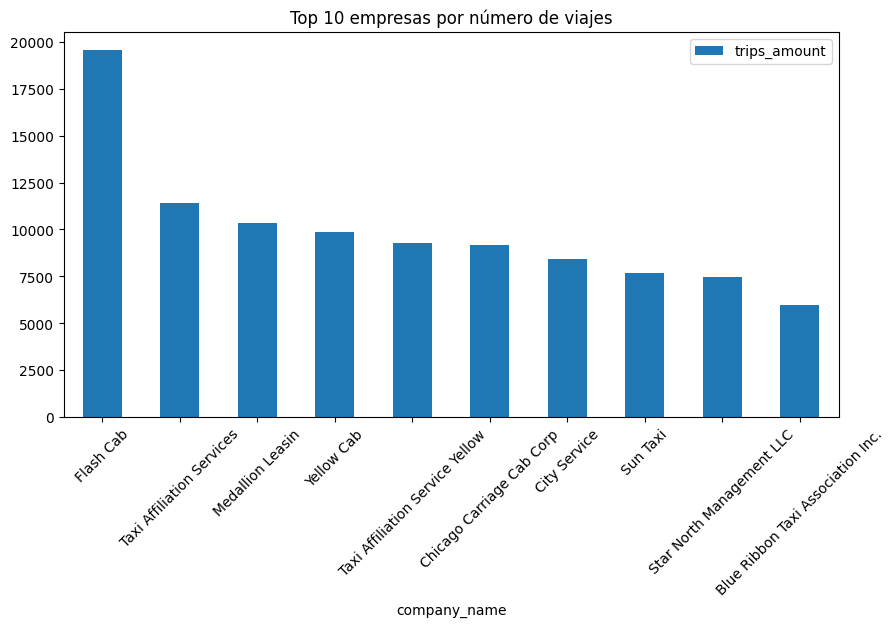

In [45]:
df_companies_sorted.head(10).plot(
    x="company_name",
    y="trips_amount",
    kind="bar",
    figsize=(10,5)
)

plt.title("Top 10 empresas por número de viajes")
plt.xticks(rotation=45)
plt.show()

Se observa que algunas empresas concentran una mayor cantidad de viajes,
lo que sugiere una posible dominancia en el mercado.

Esto puede estar relacionado con factores como la disponibilidad de vehículos,
la reputación del servicio o la cobertura en zonas de alta demanda.

In [46]:
df_companies_sorted.head(3)

,company_name,trips_amount
0,Flash Cab,19558
1,Taxi Affiliation Services,11422
2,Medallion Leasin,10367


Las 3 empresas con mayor número de viajes son las principales competidoras en el mercado.

In [47]:
# filtro viajes con lluvia
rainy = df_rides[df_rides["weather_conditions"] == "Bad"]["duration_seconds"]

# filtro viajes sin lluvia
clear = df_rides[df_rides["weather_conditions"] == "Good"]["duration_seconds"]

Se separaron los datos en dos grupos:
- viajes con condiciones climáticas desfavorables (lluvia)
- viajes con condiciones favorables (sin lluvia)

Hipótesis nula (H0):
La duración promedio de los viajes es igual en días lluviosos y no lluviosos.

Hipótesis alternativa (H1):
La duración promedio de los viajes es diferente en días lluviosos.

In [49]:
rainy.mean(), clear.mean()

(np.float64(2427.2055555555557), np.float64(1999.6756756756756))

Se compararon las medias de ambos grupos.

Se observa que la duración promedio de los viajes es mayor en condiciones de lluvia que en condiciones normales.

Sin embargo, para confirmar si esta diferencia es estadísticamente significativa, se realiza una prueba de hipótesis.

In [50]:
from scipy import stats

results = stats.ttest_ind(rainy, clear, equal_var=False)

print("p-value:", results.pvalue)

p-value: 6.738994326108735e-12


Se utilizó una prueba t para dos muestras independientes, ya que se comparan las medias de duración de dos grupos distintos:
viajes con clima desfavorable y viajes con clima favorable.

Se usó `equal_var=False` para no asumir que ambos grupos tienen varianzas iguales.

Se utilizó un nivel de significancia de 0.05.

El valor p obtenido es mucho menor a 0.05, por lo tanto se rechaza la hipótesis nula.

Esto indica que la duración de los viajes sí cambia en condiciones de lluvia.

Es decir, existe una diferencia estadísticamente significativa entre la duración de los viajes en días lluviosos y no lluviosos.

## Conclusiones

A partir del análisis realizado se identificaron patrones importantes en los datos.

Los barrios con mayor número de viajes corresponden a zonas con alta concentración de demanda de transporte, posiblemente asociadas a áreas comerciales o de tránsito elevado,
lo que sugiere una mayor demanda de servicios de transporte en estas áreas.

Asimismo, se observó que algunas empresas concentran la mayor cantidad de viajes,
lo que indica una posible dominancia en el mercado.

Finalmente, mediante la prueba de hipótesis se comprobó que las condiciones climáticas
influyen en la duración de los viajes, ya que en días lluviosos los tiempos cambian
de manera significativa.

Estos resultados permiten comprender mejor el comportamiento del servicio de transporte
y los factores que influyen en su operación.